# ROC Curve

Conda environment for this notebook is in `development/plots/environment.yml`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotting

# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

Overlapping comparison of baseline and quantized and ondboard verification

In [2]:
prediction_dir = 'predictions/'

y_true = np.load("y_test.npy")
y_baseline = np.load("y_baseline.npy") # generated from baseline keras model
classes = np.load("classes.npy", allow_pickle=True)

In [3]:
def dut_roc(prediction_path, plotname):
    y_dut = np.load(prediction_path)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    _ = plotting.makeRoc(y_true, y_baseline, classes, linestyle="-")
    plt.gca().set_prop_cycle(None)  # reset the colors
    _ = plotting.makeRoc(y_true, y_dut, classes, linestyle="--")
    plt.gca().set_prop_cycle(None)  # reset the colors
    #ax.set_title("Logarithmic x-axis", size='x-large')

    plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"export/ROC_{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

Searching for predictions in predictions/
predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_latency_bitfile.npy


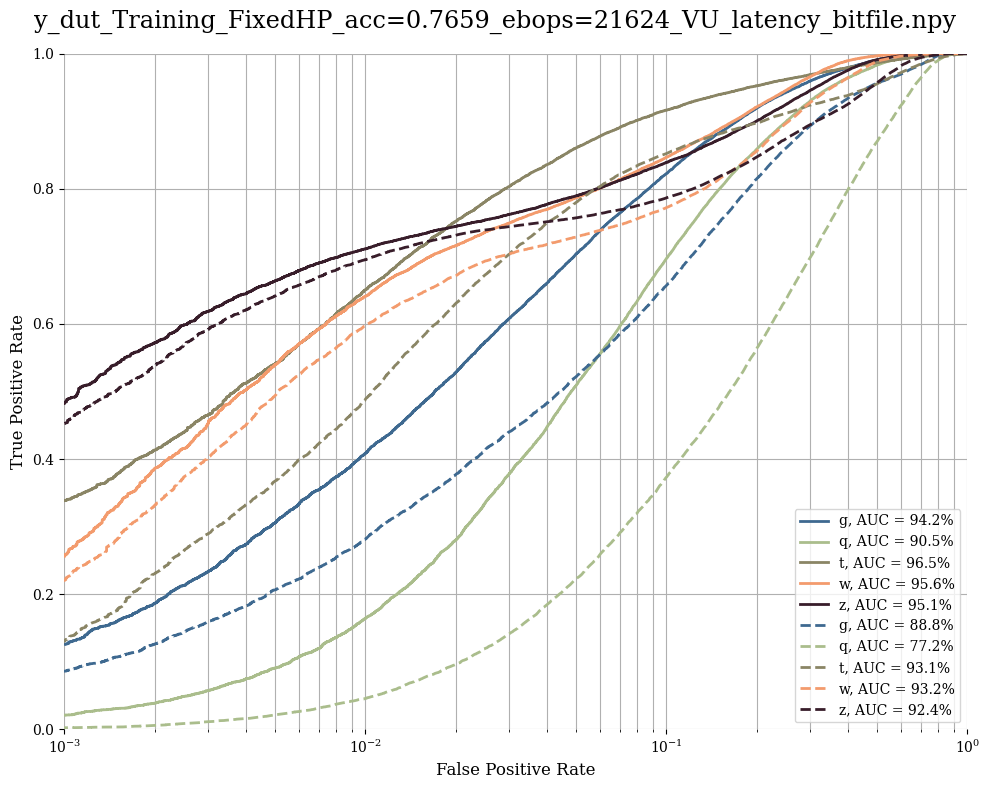

predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_latency_bitfile.npy


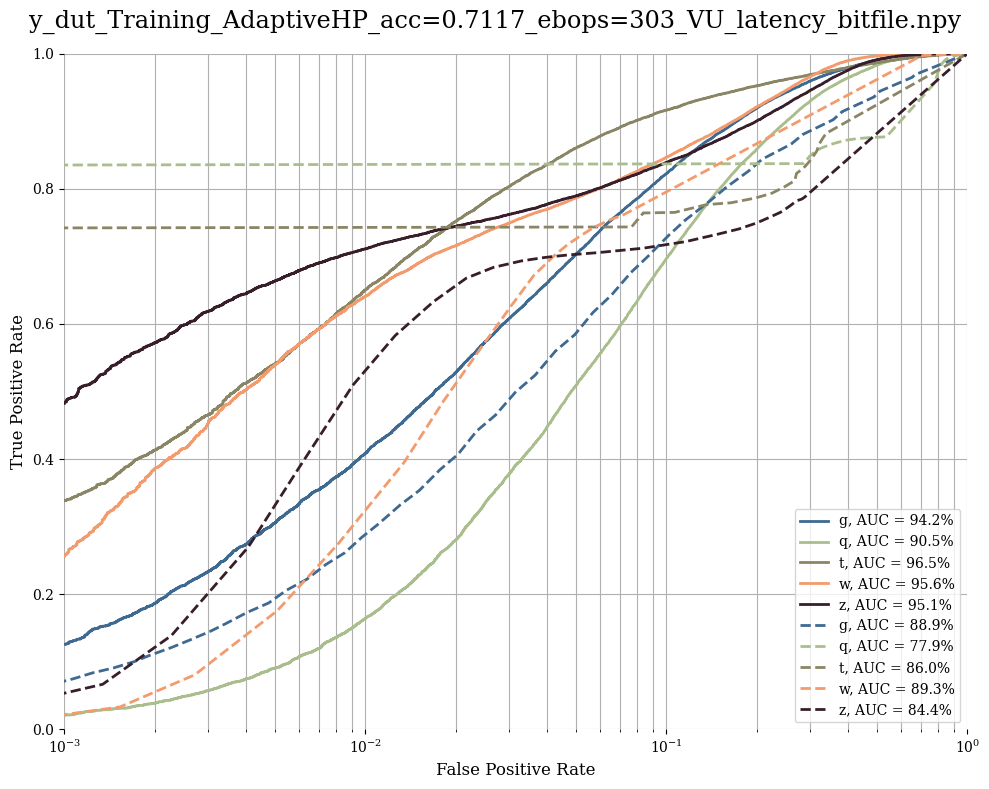

predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_DA_bitfile.npy


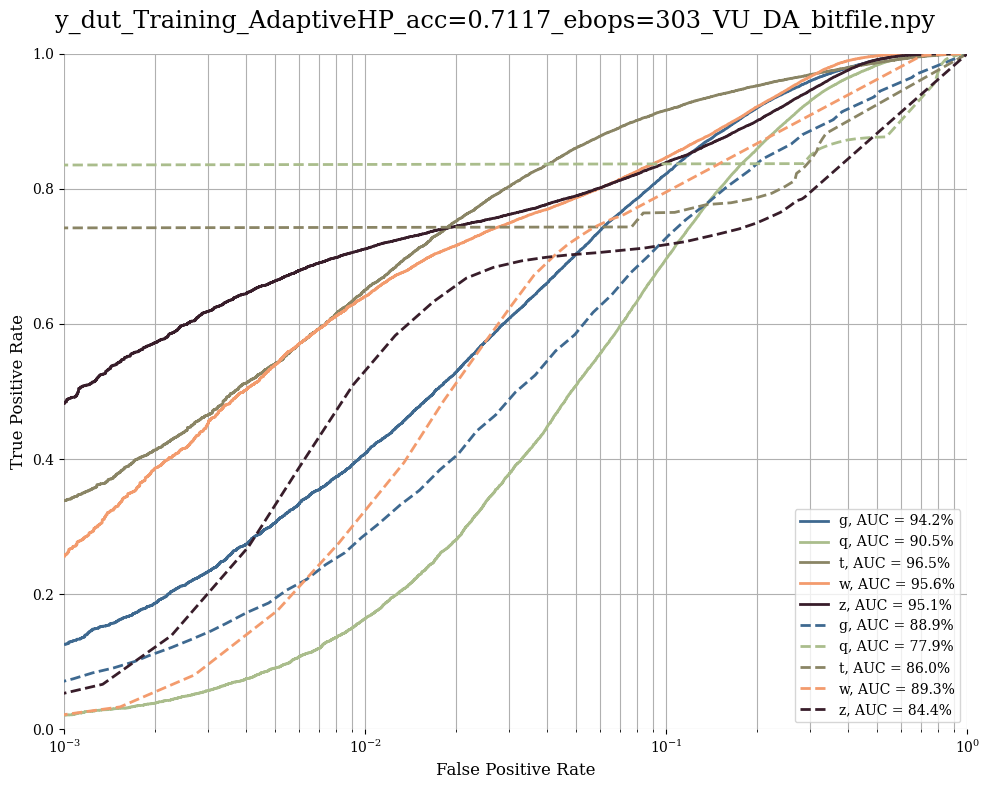

predictions/y_dut_Training_AdaptiveHP_acc=0.7512_ebops=2895_VU_DA_bitfile.npy


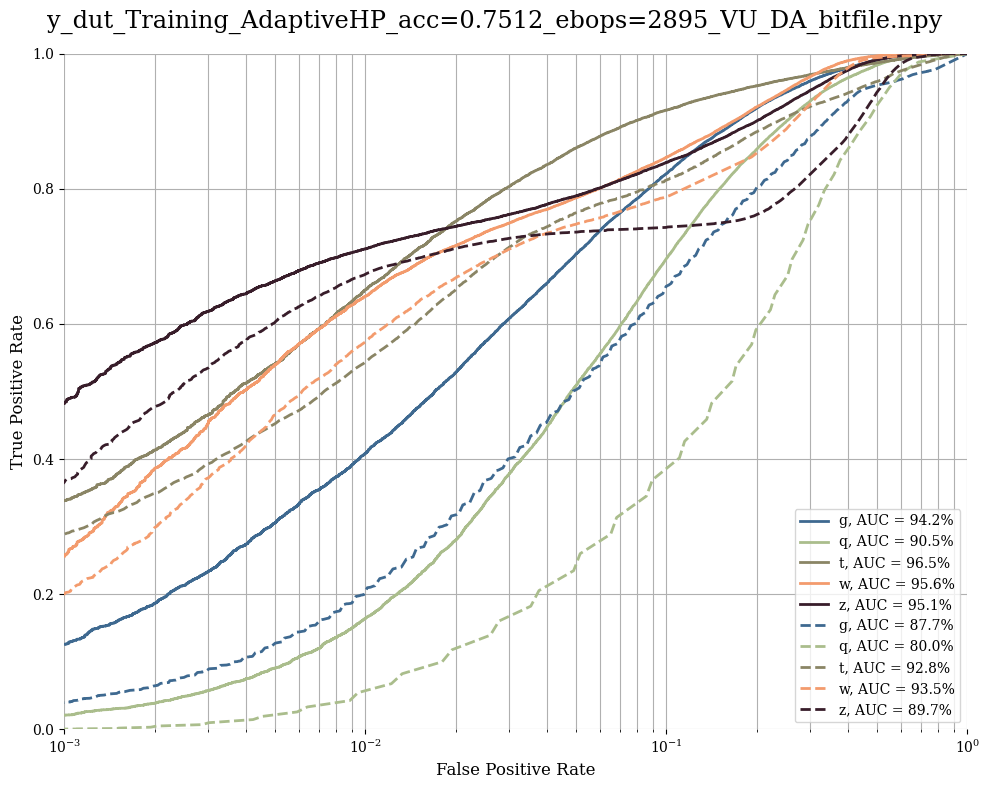

predictions/y_dut_Training_AdaptiveHP_acc=0.7426_ebops=1001_VU_DA_bitfile.npy


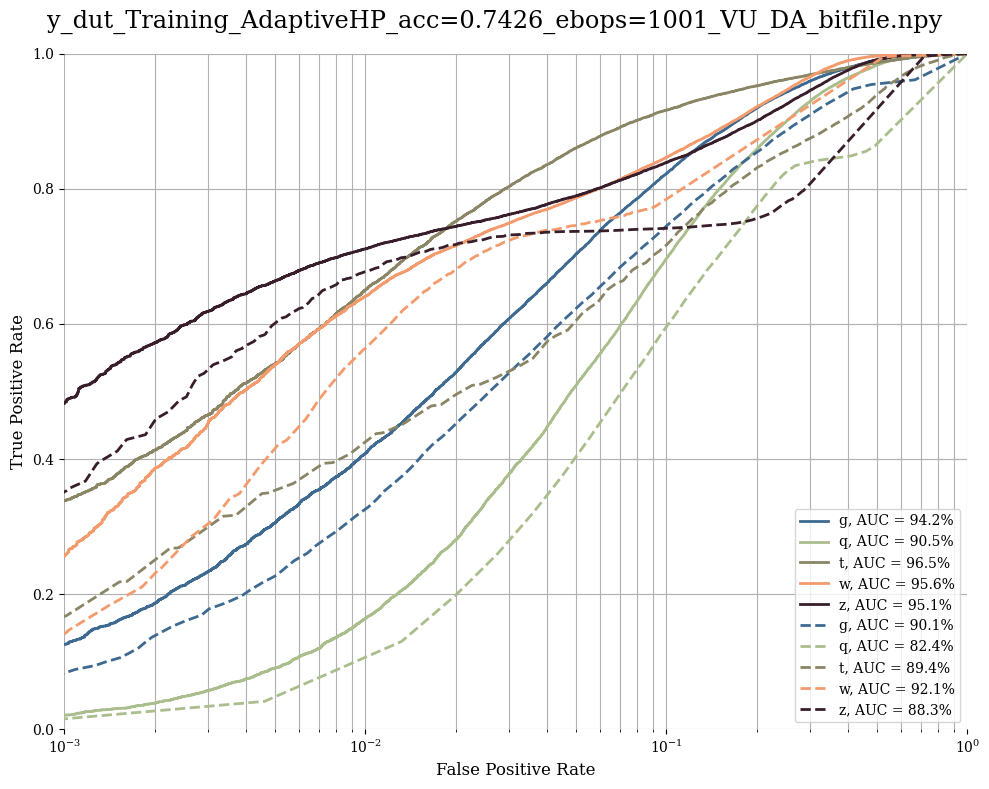

predictions/y_dut_QKeras_acc=0.7298_VU_DA_bitfile.npy


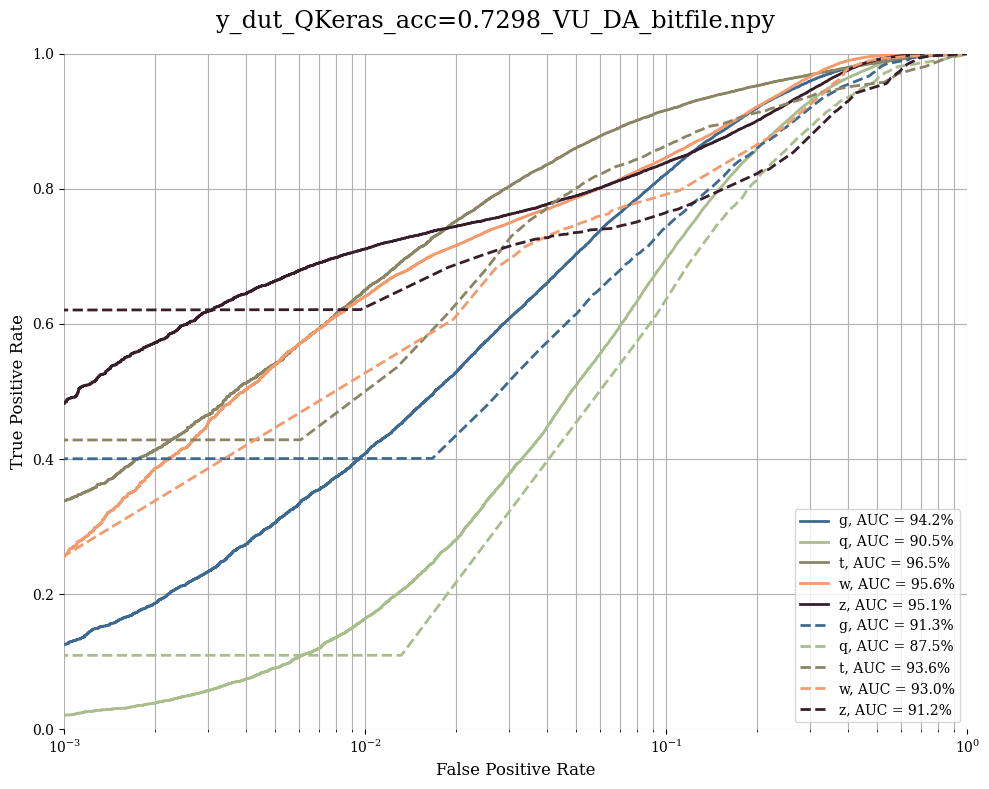

predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_DA_bitfile.npy


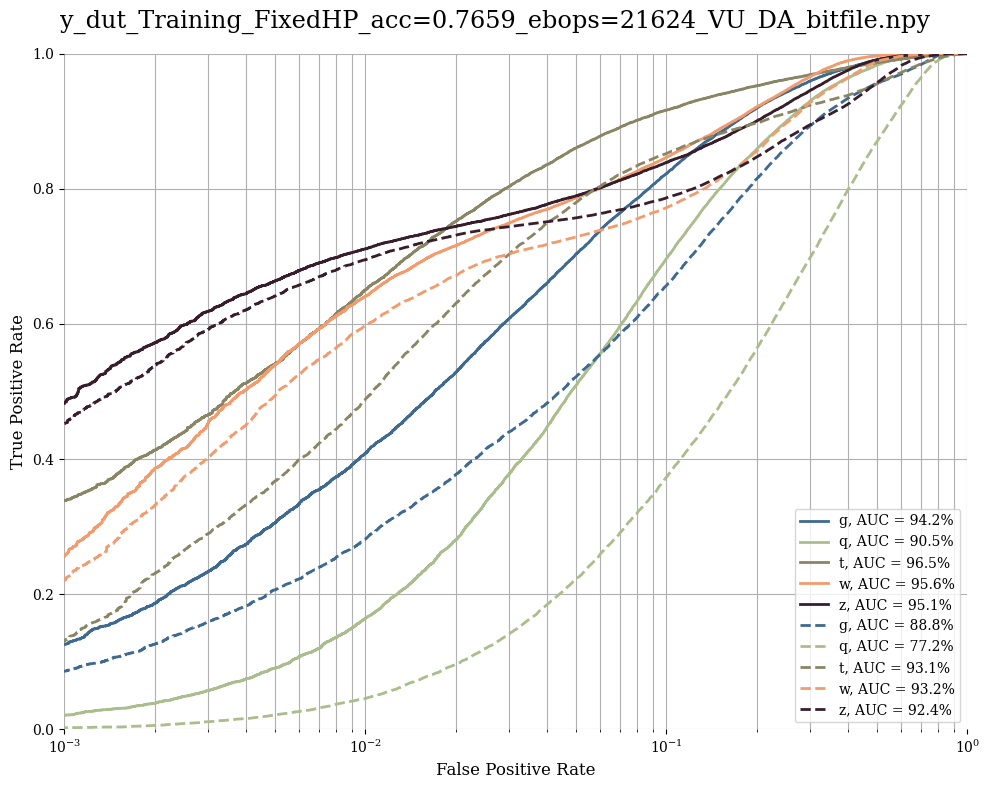

predictions/y_dut_Training_FixedHP_acc=0.7590_ebops=11634_VU_DA_bitfile.npy


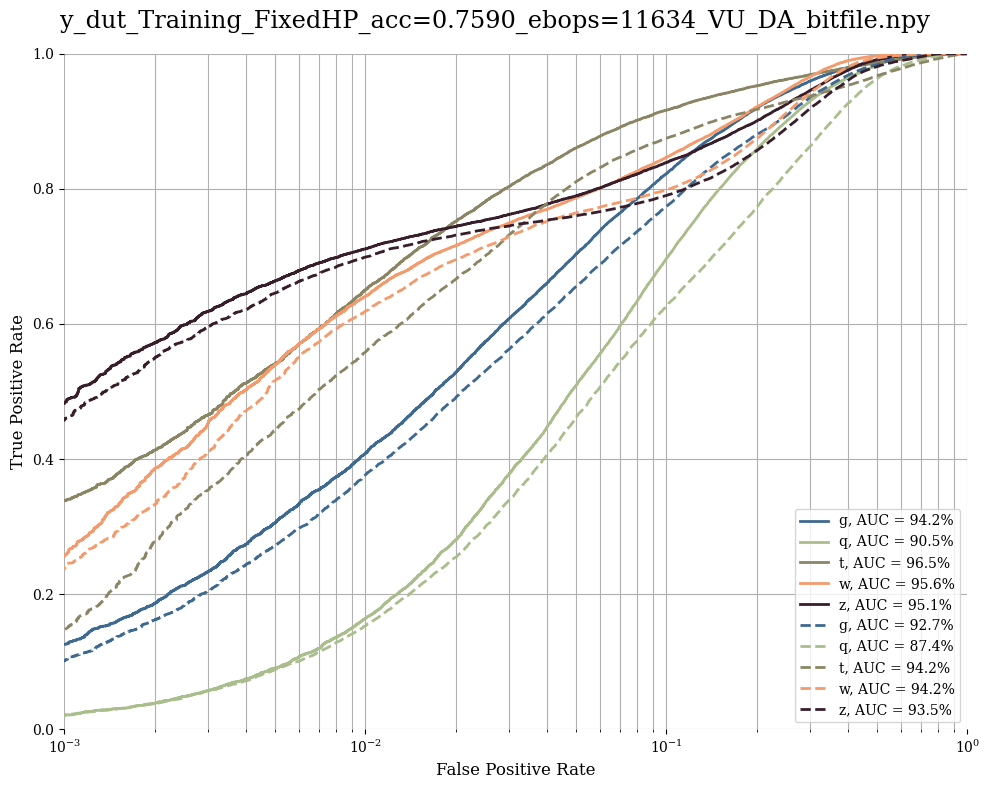

In [4]:
from pathlib import Path

paths = []
print(f"Searching for predictions in {prediction_dir}")
for prediction_path in Path(prediction_dir).rglob('*.npy'):
    print(prediction_path)
    dut_roc(prediction_path, str(prediction_path.name))
    paths.append(prediction_path)


In [13]:
for p in paths:
    print(p)

predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_latency_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_latency_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_DA_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7512_ebops=2895_VU_DA_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7426_ebops=1001_VU_DA_bitfile.npy
predictions/y_dut_QKeras_acc=0.7298_VU_DA_bitfile.npy
predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_DA_bitfile.npy
predictions/y_dut_Training_FixedHP_acc=0.7590_ebops=11634_VU_DA_bitfile.npy


Choose the plots you want to finalize for report

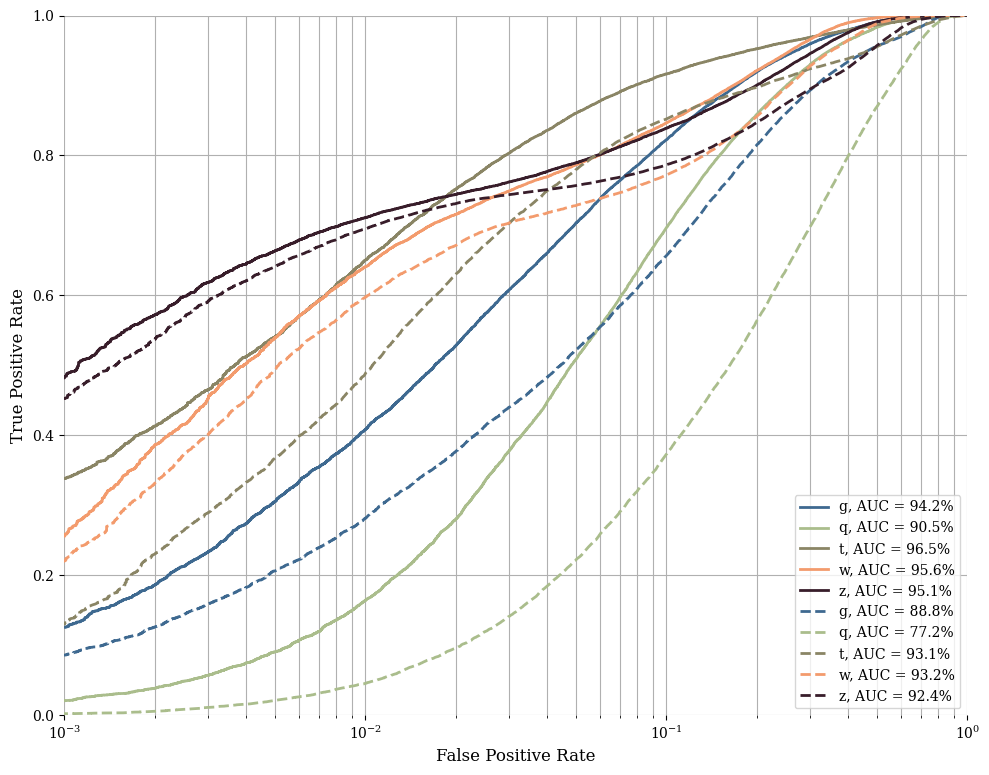

In [7]:
prediction_path = 'predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_latency_bitfile.npy'
plotname = ''

dut_roc(prediction_path, plotname)

In [8]:
y_dut = np.load(prediction_path)
y_dut

array([[ 3.296875  ,  2.578125  , -1.3535156 ,  1.2167969 ,  1.234375  ],
       [ 0.8515625 ,  3.7167969 , -1.7949219 ,  1.96875   ,  1.8554688 ],
       [ 4.0185547 ,  3.9140625 ,  5.1875    , -1.453125  , -0.1015625 ],
       ...,
       [-0.984375  ,  0.44726562, -0.0390625 ,  3.2753906 ,  0.82421875],
       [ 3.0205078 ,  4.1464844 ,  6.529297  , -3.2304688 , -1.3320312 ],
       [-1.0234375 , -0.328125  ,  0.37304688,  3.3808594 , -0.12109375]],
      shape=(166000, 5), dtype=float32)